# 01_eda

Home Credit Default Risk — capstone Module 1


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA_DIR = '../data/'

## 1. Load & Inspect `application_train.csv`

In [22]:
df = pd.read_csv(DATA_DIR + 'application_train.csv')

print("Shape:", df.shape)
print("\nColumn dtypes summary:")
print(df.dtypes.value_counts())

Shape: (307511, 122)

Column dtypes summary:
float64    65
int64      41
object     16
Name: count, dtype: int64


In [23]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"\nNumeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

df.head()


Numeric columns: 106
Categorical columns: 16


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


**Interpretation:** 

- The dataset contains 307,511 loan applications with 122 columns: 106 numeric (65 float64, 41 int64) and 16 categorical (object). 

- The presence of NaN values as early as row 3 (e.g. AMT_REQ_CREDIT_BUREAU_*) confirms that missing-data handling will be required.

- describe() confirms the ~8% default rate (TARGET mean = 0.081). Several financial columns show extreme right-skew — AMT_INCOME_TOTAL's max (117M) is wildly out of range from its 75th percentile (202K), and AMT_REQ_CREDIT_BUREAU_QRT's max of 261 inquiries in a quarter looks like a data anomaly worth investigating in preprocessing.

- The FLAG_DOCUMENT_* columns (0/1) are likely binary indicators for documents provided — often low-variance, worth checking later whether they carry any signal.

## 2. Missing Data Report

In [26]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing_values / len(df)) * 100
missing_report = missing_percentage[missing_percentage > 0].to_frame(name='pct_missing')
missing_report['count_missing'] = missing_values[missing_report.index]
missing_report

,pct_missing,count_missing
COMMONAREA_AVG,69.872297,214865
COMMONAREA_MODE,69.872297,214865
COMMONAREA_MEDI,69.872297,214865
NONLIVINGAPARTMENTS_MEDI,69.432963,213514
NONLIVINGAPARTMENTS_MODE,69.432963,213514
...,...,...
EXT_SOURCE_2,0.214626,660
AMT_GOODS_PRICE,0.090403,278
AMT_ANNUITY,0.003902,12
CNT_FAM_MEMBERS,0.000650,2


In [27]:
print("Number of fully non-null columns: ", df.notnull().all().sum())
print("Number of columns with missing values: ", missing_report.shape[0])

Number of fully non-null columns:  55
Number of columns with missing values:  67


In [28]:
print(f"Columns with >50% missing: {(missing_report['pct_missing'] > 50).sum()}")
print(f"Columns with >5% missing: {(missing_report['pct_missing'] > 5).sum()}")

missing_report.head(20)

Columns with >50% missing: 41
Columns with >5% missing: 57


,pct_missing,count_missing
COMMONAREA_AVG,69.872297,214865
COMMONAREA_MODE,69.872297,214865
COMMONAREA_MEDI,69.872297,214865
NONLIVINGAPARTMENTS_MEDI,69.432963,213514
NONLIVINGAPARTMENTS_MODE,69.432963,213514
NONLIVINGAPARTMENTS_AVG,69.432963,213514
FONDKAPREMONT_MODE,68.386172,210295
LIVINGAPARTMENTS_AVG,68.354953,210199
LIVINGAPARTMENTS_MEDI,68.354953,210199
LIVINGAPARTMENTS_MODE,68.354953,210199


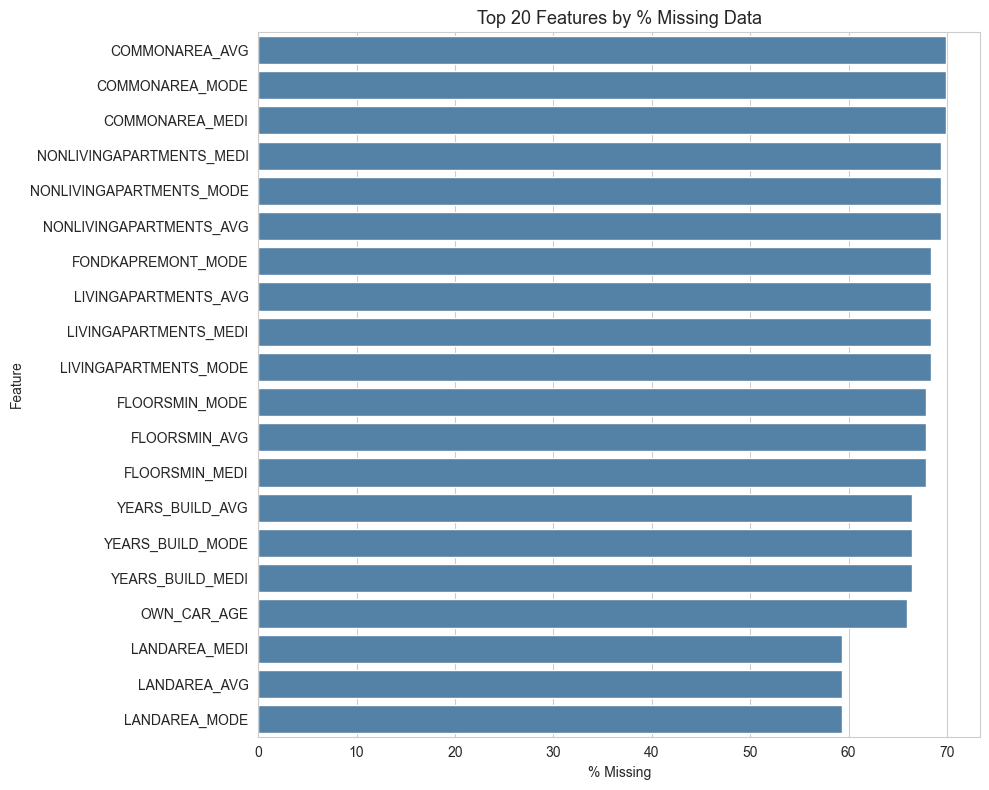

In [29]:
plt.figure(figsize=(10, 8))
top_missing = missing_report.head(20)
sns.barplot(x=top_missing['pct_missing'], y=top_missing.index, color='steelblue')
plt.title('Top 20 Features by % Missing Data', fontsize=13)
plt.xlabel('% Missing')
plt.ylabel('Feature')
plt.tight_layout()

os.makedirs('../figs', exist_ok=True)
plt.savefig('../figs/missing_data_barplot.png', dpi=300)
plt.show()


In [30]:
df['FLAG_OWN_CAR'].value_counts()

FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

In [31]:
# Cross-referencing
pd.crosstab(df['FLAG_OWN_CAR'], df['OWN_CAR_AGE'].isnull())

OWN_CAR_AGE,False,True
FLAG_OWN_CAR,,
N,0,202924
Y,104582,5


**Interpretation:** 

- 41 columns have more than 50% missing data, dominated by property/building characteristics (COMMONAREA_*, NONLIVINGAPARTMENTS_*, LIVINGAPARTMENTS_*, YEARS_BUILD_*, LANDAREA_* — all clustered around 60-70% missing). These are almost certainly features about the applicant's building/apartment that simply weren't collected or don't apply to many applicants (e.g. renters vs. owners). 

- OWN_CAR_AGE is missing for 202,929 applicants. Cross-referencing with FLAG_OWN_CAR shows 202,924 of these (99.998%) correspond to applicants who don't own a car — a structural absence, not a data quality issue. Since 0 is a plausible real value for a brand-new car, these will be imputed as -1 in preprocessing (an out-of-range sentinel) rather than treating them as random missingness. The remaining 5 missing values (among car owners) appear to be genuine data entry gaps, best imputed with the median car age among car owners.

## 3. Explore the Target Variable

In [32]:
target_dist = df['TARGET'].value_counts(normalize=True)
print(target_dist)
print(f"\nClass imbalance ratio: {target_dist[0] / target_dist[1]:.1f} : 1 (non-default : default)")

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Class imbalance ratio: 11.4 : 1 (non-default : default)


/var/folders/g9/n8rt3n4j0v5208rnv8pfvgwh0000gn/T/ipykernel_28348/157728236.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET', data=df, palette=['steelblue', 'indianred'])


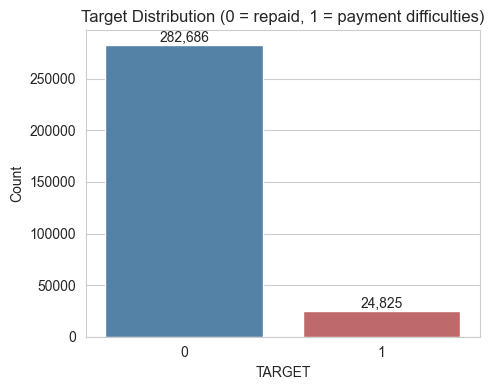

In [33]:
plt.figure(figsize=(5, 4))
sns.countplot(x='TARGET', data=df, palette=['steelblue', 'indianred'])
plt.title('Target Distribution (0 = repaid, 1 = payment difficulties)')
plt.xlabel('TARGET')
plt.ylabel('Count')
for i, v in enumerate(df['TARGET'].value_counts().sort_index()):
    plt.text(i, v + 3000, f'{v:,}', ha='center')
plt.tight_layout()
plt.savefig('../figs/target_distribution.png', dpi=300)
plt.show()

**Interpretation:**

The dataset is highly imbalanced: 282,686 applicants (91.9%) repaid on time (TARGET=0) versus 24,825 (8.1%) who experienced payment difficulties (TARGET=1) — a ratio of roughly 11.4 non-defaults for every 1 default. This confirms the imbalance mentioned in the project brief and means accuracy is not a valid evaluation metric (a model that always predicts "no default" would score ~92% while being useless). This motivates using AUROC/AUPRC as primary metrics and applying class_weight='balanced' (or similar techniques like SMOTE) during modeling in Step 3.

## 4. Default Rate by Segment

In [34]:
segment_cols = ['NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']

for col in segment_cols:
    rates = df.groupby(col)['TARGET'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    rates.columns = ['default_rate', 'n_applicants']
    print(f"\n--- Default rate by {col} (top 10) ---")
    print(rates.head(10))



--- Default rate by NAME_CONTRACT_TYPE (top 10) ---
                    default_rate  n_applicants
NAME_CONTRACT_TYPE                            
Cash loans              0.083459        278232
Revolving loans         0.054783         29279

--- Default rate by NAME_INCOME_TYPE (top 10) ---
                      default_rate  n_applicants
NAME_INCOME_TYPE                                
Maternity leave           0.400000             5
Unemployed                0.363636            22
Working                   0.095885        158774
Commercial associate      0.074843         71617
State servant             0.057550         21703
Pensioner                 0.053864         55362
Businessman               0.000000            10
Student                   0.000000            18

--- Default rate by OCCUPATION_TYPE (top 10) ---
                      default_rate  n_applicants
OCCUPATION_TYPE                                 
Low-skill Laborers        0.171524          2093
Drivers              

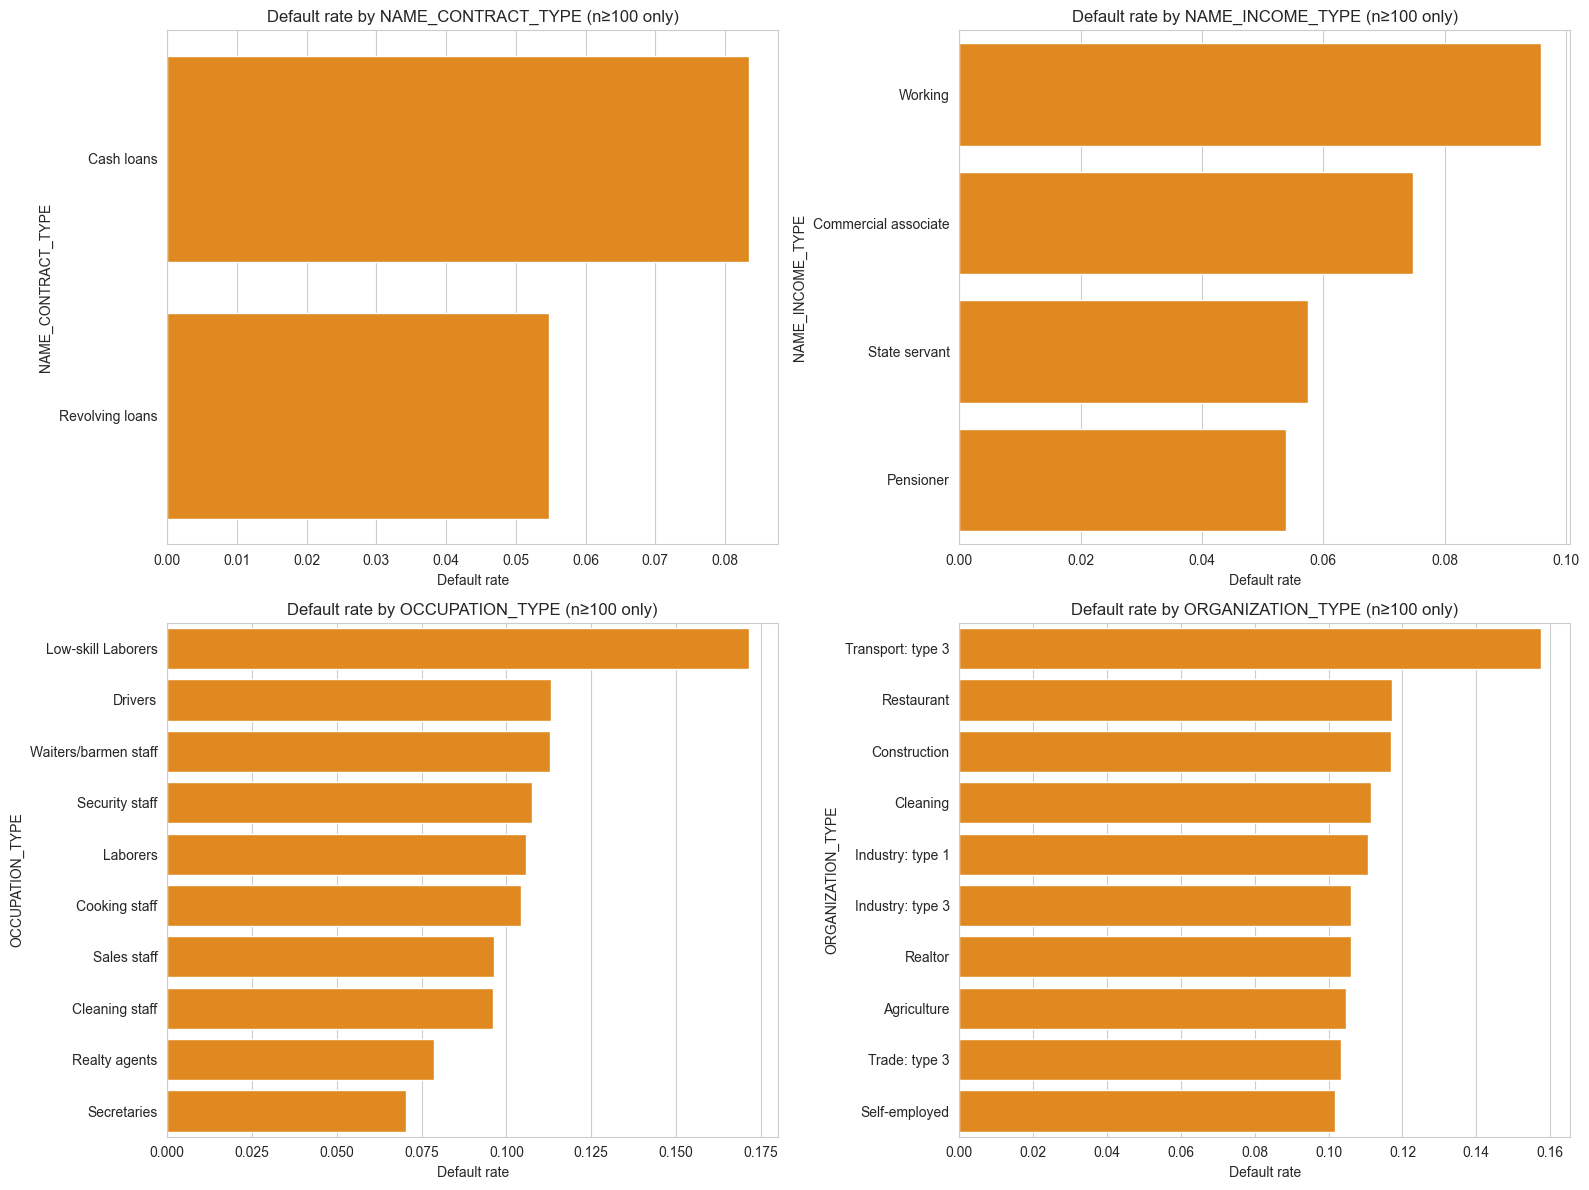

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, col in zip(axes.flatten(), segment_cols):
    rates = df.groupby(col)['TARGET'].agg(['mean', 'count'])
    rates = rates[rates['count'] >= 100]  # filtre les groupes trop petits
    rates = rates.sort_values('mean', ascending=False).head(10)
    sns.barplot(x=rates['mean'], y=rates.index, ax=ax, color='darkorange')
    ax.set_title(f'Default rate by {col} (n≥100 only)')
    ax.set_xlabel('Default rate')
plt.tight_layout()
plt.savefig('../figs/default_rate_by_segment.png', dpi=300)
plt.show()

**Interpretation:**

Segments with reliable sample sizes show meaningful default rate differences: 
* Cash loans default more than Revolving loans (8.3% vs 5.5%), and Low-skill Laborers stand out among occupations (17.2% default rate, n=2,093). 

* However, several top-ranked segments (e.g. Maternity leave 40%, Unemployed 36.4%, Businessman 0%) have very small sample sizes (n<25) and should not be trusted as reliable signals — their extreme rates are likely due to small-sample noise rather than genuine risk patterns. Any feature engineering from these categorical variables should account for sample size, e.g. by grouping rare categories together.

## 5. Distributions of Key Features

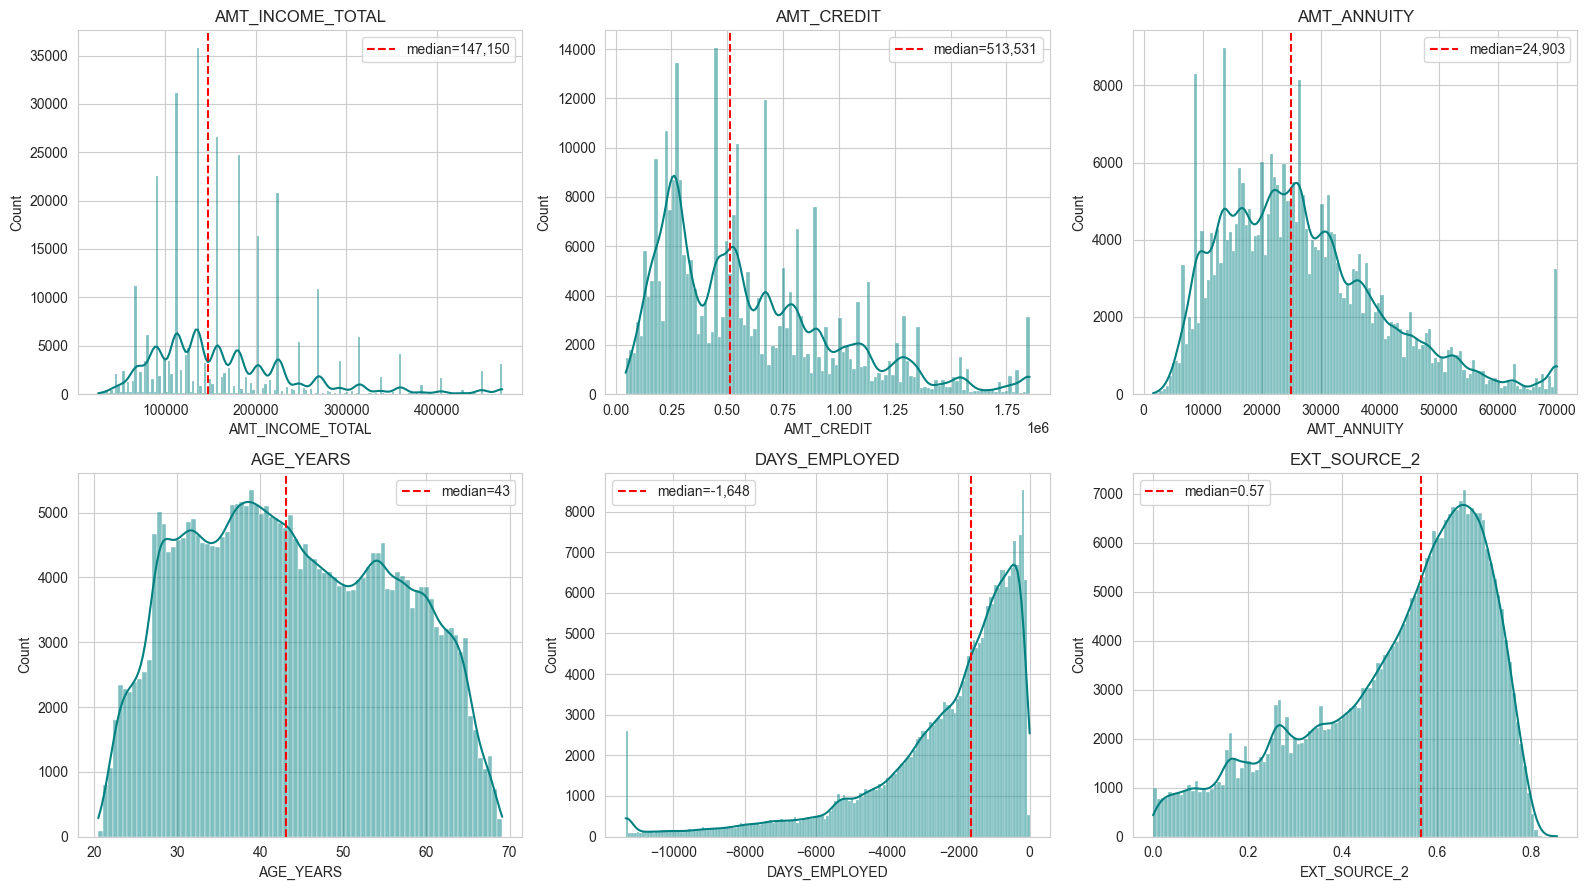

In [ ]:
df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365

dist_features = {
    'AMT_INCOME_TOTAL': df['AMT_INCOME_TOTAL'].clip(upper=df['AMT_INCOME_TOTAL'].quantile(0.99)),
    'AMT_CREDIT': df['AMT_CREDIT'].clip(upper=df['AMT_CREDIT'].quantile(0.99)),
    'AMT_ANNUITY': df['AMT_ANNUITY'].clip(upper=df['AMT_ANNUITY'].quantile(0.99)),
    'AGE_YEARS': df['AGE_YEARS'],
    'DAYS_EMPLOYED': df['DAYS_EMPLOYED'].replace(365243, np.nan).clip(lower=df['DAYS_EMPLOYED'].replace(365243, np.nan).quantile(0.01)),
    'EXT_SOURCE_2': df['EXT_SOURCE_2'],
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (name, series) in zip(axes.flatten(), dist_features.items()):
    sns.histplot(series.dropna(), kde=True, ax=ax, color='teal')
    median_val = series.median()
    if abs(median_val) < 10:
        label = f'median={median_val:.2f}'  # 2 décimales pour les petites valeurs (EXT_SOURCE_2, ratios)
    else:
        label = f'median={median_val:,.0f}'  # arrondi entier pour les gros montants
    ax.axvline(median_val, color='red', linestyle='--', label=label)
    ax.set_title(name)
    ax.legend()
plt.tight_layout()
plt.savefig('../figs/key_feature_distributions.png', dpi=300)
plt.show()

In [41]:
print(df['DAYS_EMPLOYED'].value_counts().head(10))

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-230         151
-199         151
-212         150
-384         143
-229         143
-231         140
-207         138
Name: count, dtype: int64


**Interpretation:**

- `AMT_INCOME_TOTAL`, `AMT_CREDIT`, and `AMT_ANNUITY` all show clear right-skew even after clipping the top 1% — most applicants cluster at lower amounts, with several sharp spikes suggesting people tend to request "round" loan amounts rather than arbitrary values. `AGE_YEARS` is fairly evenly spread between 20-70 with a median of 43, showing a slight secondary peak around 55. `DAYS_EMPLOYED` is heavily concentrated near 0 (recently employed) with a long tail toward more negative values (longer tenure) — consistent with the sentinel cleanup applied earlier. `EXT_SOURCE_2`, the most predictive feature in the dataset, is left-skewed with most applicants scoring between 0.4-0.8 and a median of 0.57.

- A sanity check on `AMT_ANNUITY` (median 24,903) against `AMT_INCOME_TOTAL` (median 147,150) suggests this is likely an **annual** payment rather than monthly — treating it as monthly would imply a median DTI over 200%, which is unrealistic. This needs to be confirmed in Step 2 before computing `ANNUITY_INCOME_RATIO`.

## 6. Correlation Heatmap — Top 15 Features vs TARGET

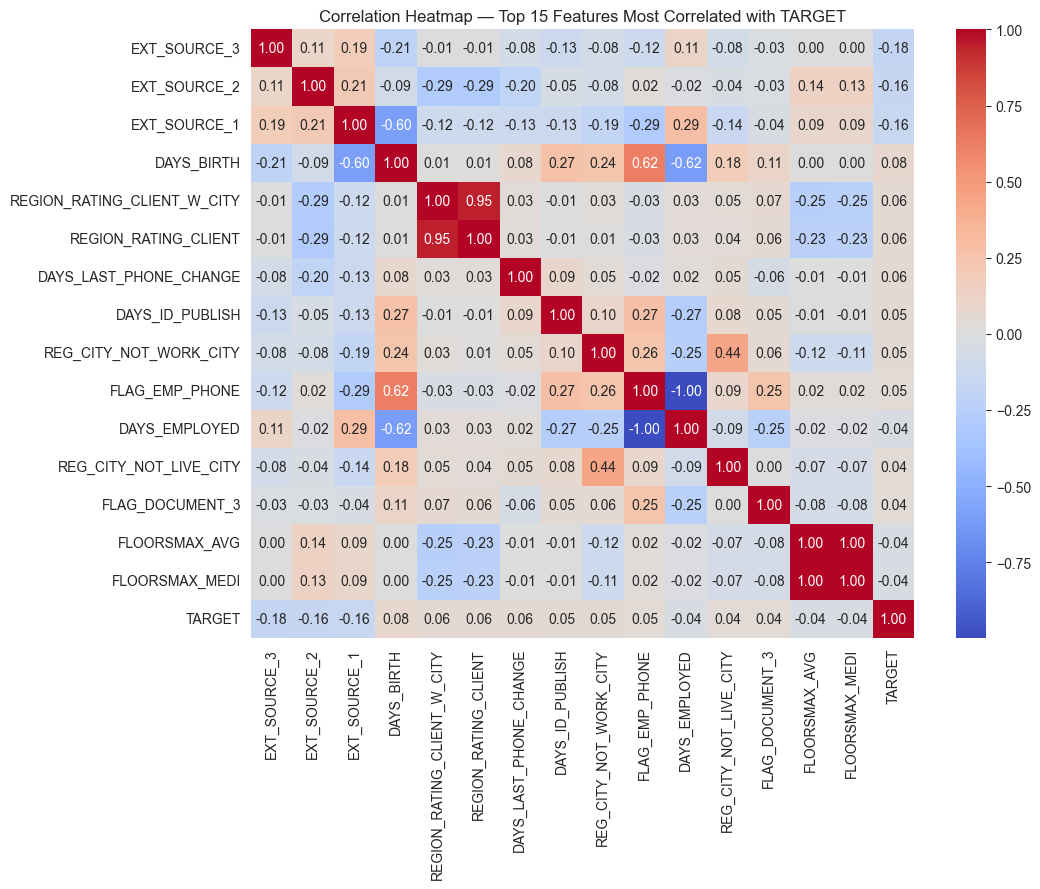

Top 15 features by |correlation| with TARGET:
EXT_SOURCE_3                   0.178919
EXT_SOURCE_2                   0.160472
EXT_SOURCE_1                   0.155317
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
DAYS_EMPLOYED                  0.044932
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
FLOORSMAX_AVG                  0.044003
FLOORSMAX_MEDI                 0.043768
Name: TARGET, dtype: float64


In [43]:
correlations = df[numeric_cols].corr()['TARGET'].drop('TARGET').abs().sort_values(ascending=False)
top15 = correlations.head(15).index.tolist()

plt.figure(figsize=(11, 9))
sns.heatmap(df[top15 + ['TARGET']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Top 15 Features Most Correlated with TARGET')
plt.tight_layout()
plt.savefig('../figs/correlation_heatmap_top15.png', dpi=300)
plt.show()

print("Top 15 features by |correlation| with TARGET:")
print(correlations.head(15))


In [44]:
pd.crosstab(df['DAYS_EMPLOYED'] == 365243, df['FLAG_EMP_PHONE'])

FLAG_EMP_PHONE,0,1
DAYS_EMPLOYED,,
False,12,252125
True,55374,0


- Cross-tabulation confirms FLAG_EMP_PHONE is almost perfectly redundant with employment status derived from DAYS_EMPLOYED (99.995% agreement, only 12 exceptions out of 307,511 rows). 

**Interpretation:**

EXT_SOURCE_1/2/3 confirm as the top predictors of TARGET (correlations 0.16-0.18), consistent with the finance background material. However, even the strongest correlation is weak in absolute terms (<0.2), suggesting linear correlation alone underestimates these features' true predictive power — likely due to non-linear relationships better captured by tree-based models. 

Notably, FLAG_EMP_PHONE and DAYS_EMPLOYED show a perfect -1.00 correlation, indicating redundant/deterministic encoding (confirmed via cross-tab: FLAG_EMP_PHONE agrees with employment status derived from DAYS_EMPLOYED in 99.995% of rows) — worth investigating for potential feature dropping in Step 2 to avoid multicollinearity. 

Similarly, REGION_RATING_CLIENT and REGION_RATING_CLIENT_W_CITY (0.95) and FLOORSMAX_AVG/FLOORSMAX_MEDI (1.00) appear near-duplicate and are multicollinearity candidates.

## 7. Bureau Data — First Look

In [46]:
bureau = pd.read_csv(DATA_DIR + 'bureau.csv')
bureau.head()


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [47]:

print("bureau.csv shape:", bureau.shape)
print(f"Unique applicants in bureau.csv: {bureau['SK_ID_CURR'].nunique()}")

bureau.csv shape: (1716428, 17)
Unique applicants in bureau.csv: 305811


In [51]:
bureau_counts = bureau.groupby('SK_ID_CURR').size().rename('num_bureau_records')
app = df.merge(bureau_counts, on='SK_ID_CURR', how='left')
app.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,num_bureau_records
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0.0,0.0,0.0,0.0,0.0,1.0,25.920548,8.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,45.931507,4.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,52.180822,2.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,52.068493,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,54.608219,1.0


In [52]:
app.shape

(307511, 124)

In [53]:
app['num_bureau_records'] = app['num_bureau_records'].fillna(0)

In [54]:
print("\nDistribution of num_bureau_records:")
print(app['num_bureau_records'].describe())


Distribution of num_bureau_records:
count    307511.000000
mean          4.765114
std           4.496199
min           0.000000
25%           1.000000
50%           4.000000
75%           7.000000
max         116.000000
Name: num_bureau_records, dtype: float64


**Interpretation:**

`num_bureau_records` ranges from 0 to 116 (median 4), confirming that most applicants have a moderate credit history (1-7 prior accounts), while a smaller number have extensive credit histories. About 1,700 applicants (307,511 - 305,811) have no bureau records at all, now correctly encoded as 0 rather than NaN after the left-merge and fillna.

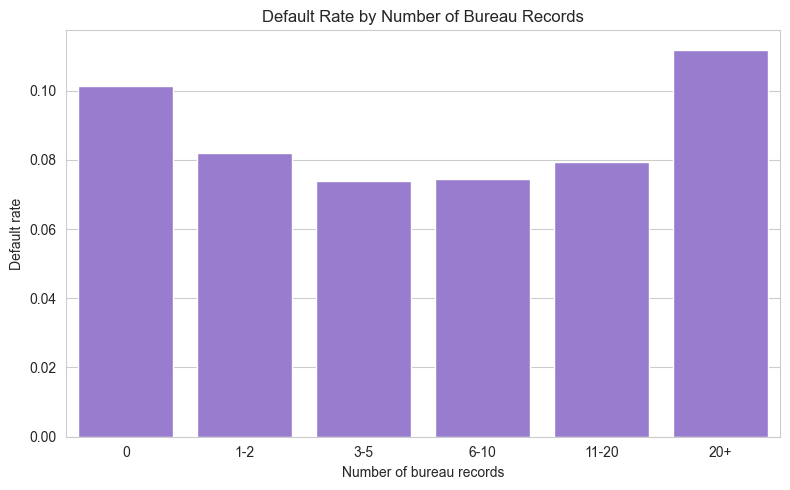

In [56]:
app['bureau_record_bucket'] = pd.cut(
    app['num_bureau_records'],
    bins=[-1, 0, 2, 5, 10, 20, 1000],
    labels=['0', '1-2', '3-5', '6-10', '11-20', '20+']
)

rate_by_bucket = app.groupby('bureau_record_bucket', observed=True)['TARGET'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=rate_by_bucket.index, y=rate_by_bucket.values, color='mediumpurple')
plt.title('Default Rate by Number of Bureau Records')
plt.xlabel('Number of bureau records')
plt.ylabel('Default rate')
plt.tight_layout()
plt.savefig('../figs/default_rate_by_bureau_records.png', dpi=300)
plt.show()


**Interpretation:**

Default rate follows a U-shaped pattern across bureau record buckets: applicants with 0 bureau records show an elevated default rate (~10.1%), likely reflecting the lender's inability to assess repayment history for "thin-file" applicants. The rate drops to its lowest point for applicants with 3-10 records (~7.4-7.5%), suggesting a moderate, established credit history is the safest signal. The rate rises again for applicants with 20+ records (~11.1%), possibly reflecting overextended credit usage — both very low and very high credit utilization signal elevated risk. This motivates engineering `num_bureau_records` (or a binned version) as a feature in Step 2, and suggests it may have a non-linear relationship with TARGET, better captured by tree-based models than logistic regression.

## Executive Summary

This EDA analyzed 307,511 loan applications across 122 features to understand the Home Credit Default Risk dataset ahead of building a credit scoring model.

**Class imbalance:** The target variable is highly imbalanced — 91.9% of applicants repaid on time versus 8.1% who experienced payment difficulties (a ~11.4:1 ratio). This rules out accuracy as a valid evaluation metric and motivates using AUROC/AUPRC alongside class-weighted or resampling techniques in Step 3.

**Missing data:** 41 columns have more than 50% missing data, dominated by property/building characteristics (COMMONAREA_*, LIVINGAPARTMENTS_*, YEARS_BUILD_*, etc.), likely reflecting applicants who don't own property. `OWN_CAR_AGE` (66% missing) was confirmed to be a structural absence rather than a data quality issue — 99.998% of missing values correspond to applicants without a car (`FLAG_OWN_CAR = 'N'`), suggesting a sentinel value (e.g. -1) rather than median imputation in preprocessing.

**Segment-level risk:** Reliable segments (n≥100) show meaningful default rate differences — Cash loans default more than Revolving loans (8.3% vs 5.5%), and Low-skill Laborers stand out among occupations (17.2%). Several apparently high-risk segments (e.g. "Maternity leave" at 40%) are small-sample artifacts and not reliable signals.

**Key predictors:** EXT_SOURCE_1/2/3 are confirmed as the strongest linear predictors of TARGET (correlations 0.16-0.18), though even the top correlation is weak in absolute terms — suggesting non-linear relationships better captured by tree-based models. A data quality issue was identified: FLAG_EMP_PHONE is 99.995% redundant with employment status derived from DAYS_EMPLOYED, a multicollinearity candidate for Step 2.

**Data unit ambiguity:** A sanity check on AMT_ANNUITY against AMT_INCOME_TOTAL suggests AMT_ANNUITY may be an annual rather than monthly figure — treating it as monthly (per the brief's suggested DTI formula) implies an unrealistic median DTI over 200%. This needs to be resolved before computing ANNUITY_INCOME_RATIO in Step 2.

**Bureau data:** Merging `bureau.csv` reveals a U-shaped relationship between credit history depth and default risk — applicants with no bureau records (10.1% default) and applicants with 20+ records (11.1% default) are both riskier than those with a moderate history of 3-10 records (~7.4-7.5%), consistent with the idea that both "thin-file" and overextended credit profiles signal elevated risk.

**Next steps (Step 2):** Handle the DAYS_EMPLOYED sentinel and OWN_CAR_AGE structural missingness, resolve the AMT_ANNUITY unit ambiguity, build missingness indicators for features with >5% missing, engineer bureau aggregation features (count, active count, max overdue, mean credit amount), and check for multicollinearity between FLAG_EMP_PHONE/DAYS_EMPLOYED and other near-duplicate feature pairs identified in the correlation heatmap.